<a href="https://colab.research.google.com/github/azholl/lis5693/blob/main/final-project/final_project_holland_min.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

To ignore deprecation warnings

In [ ]:
import warnings
warnings.simplefilter("ignore")
warnings.filterwarnings("ignore")

Installing packages

In [ ]:
%%capture
!pip install gensim pyldavis nltk textnets

Downloading list of English stopwords

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Importing libraries

In [ ]:
import pandas as pd
from nltk.corpus import stopwords
import string
import gensim.corpora as corpora
from gensim.models import LdaModel

Loading abstract data from Github. The abstracts are compiled from the top 1,000 most relevant papers that populated when using the search term "early childhood education" AND "disability" AND "special education" and the filter "has abstract" in the scholar search in lens.org.

In [ ]:
import requests
import io

url = "https://raw.githubusercontent.com/azholl/lis5693/refs/heads/main/final-project/final-project-data.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

In [ ]:
import pandas as pd

df = pd.read_csv(io.StringIO(text))
df.head()

,Lens ID,Title,Publication Year,Abstract
0,000-315-279-343-20X,Research-Based Practices for Emergent Bilingua...,2019.0,"Emergent Bilinguals (EB), particularly those o..."
1,000-340-939-801-734,Trauma-informed care in early intervention: Pr...,2026.0,Young children who receive early intervention ...
2,000-674-694-033-377,Addressing Clinician–Client Mismatch: A Prelim...,2011.0,Purpose This project examined receptive vocabu...
3,000-675-990-551-990,Examining the Use of Recommended Language Inte...,1996.0,Two studies were conducted to describe the ext...
4,000-751-399-827-912,Start with Us! Culturally Relevant Pedagogy in...,2014.0,"Using an ethnographic case study approach, we ..."


We used this dataset from The Lens because it aligns with our intersected academic interests in early childhood education and disability, and also provides a large collection of scholarly abstracts suitable for text mining. Research in this area is extensive and multidisciplinary, making it difficult to identify themes and relationships across studies using traditional methods. By analyzing this dataset, we aim to uncover patterns and connections within the literature that may not be immediately visible. The abstract column was used for modeling because it offers a concise summary of each article's content, and it is more informative than titles and more consistent than keywords (which many articles were missing) for topic modeling, network analysis, and classification.

In [ ]:
docs = df["Abstract"].dropna().tolist()
docs[0][:500]

'Emergent Bilinguals (EB), particularly those of Latino descent, who have a moderate intellectual disability (ID) are arguably one of the most underserved and under researched populations. Although ...'

Preprocessing

In [ ]:
stop_words = stopwords.words('english')

Function to clean the documents. Takes each document and returns a cleaned sequence of words with no punctuation or stop words.

In [ ]:
def clean_doc(doc):
    no_punct = ''
    for c in doc:
        if c not in string.punctuation:
            no_punct = no_punct+c
    # with list comprehension
    # no_punct = ''.join([c for c in doc if c not in string.punctuation])

    words = no_punct.lower().split()

    final_words = []
    for word in words:
        if word not in stop_words:
            final_words.append(word)

    # with list comprehension
    # final_words = [word for word in words if word not in stop_words]

    return final_words

Adding custom stopwords

In [ ]:
custom_stopwords = ['research', 'study', 'paper', 'article', 'results', 'analysis', 'data', 'methods', 'methods', 'purpose', 'aim', 'objective', 'examines', 'examined', 'investigates', 'approach', 'explores', 'education', 'child', 'children', 'childhood', 'early', 'development', 'students', 'learning', 'disability', 'disabilities', 'special', 'needs', 'researched', 'id', 'eb', 'young', 'services', 'service', 'program', 'studies', 'educational', 'used', 'years', 'skills', 'programs', 'teachers', 'families']
stop_words.extend(custom_stopwords)
print(f"New stopwords added: {custom_stopwords}")

New stopwords added: ['research', 'study', 'paper', 'article', 'results', 'analysis', 'data', 'methods', 'methods', 'purpose', 'aim', 'objective', 'examines', 'examined', 'investigates', 'approach', 'explores', 'education', 'child', 'children', 'childhood', 'early', 'development', 'students', 'learning', 'disability', 'disabilities', 'special', 'needs', 'researched', 'id', 'eb', 'young', 'services', 'service', 'program', 'studies', 'educational', 'used', 'years', 'skills', 'programs', 'teachers', 'families']


Makes sure cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.

In [ ]:
cleaned_docs = [clean_doc(doc) for doc in docs]
id2word = corpora.Dictionary(cleaned_docs)
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]

print("Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.")

cleaned_with_custom_stopwords = clean_doc(docs[0])
print("\nOriginal document (first one):")
print(docs[0])
print("\nCleaned document with custom stopwords:")
print(cleaned_with_custom_stopwords)

Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.

Original document (first one):
Emergent Bilinguals (EB), particularly those of Latino descent, who have a moderate intellectual disability (ID) are arguably one of the most underserved and under researched populations. Although ...

Cleaned document with custom stopwords:
['emergent', 'bilinguals', 'particularly', 'latino', 'descent', 'moderate', 'intellectual', 'arguably', 'one', 'underserved', 'populations', 'although']


Converts all documents into a list called clean docs

In [ ]:
cleaned_docs = [clean_doc(doc) for doc in docs]

Creates ID-Word index, LDA cannot look at words so everything must be converted to numbers.

In [ ]:
id2word = corpora.Dictionary(cleaned_docs)

Converting all documents into a sequence of numbers using doc2bow

In [ ]:
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]
print(corpus[0])

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1)]


Seeing what words the numbers correspond to by mapping each number to the ID-Word index

In [ ]:
for num in corpus[0]:
    num = num[0]
    print(f"{num}\t{id2word[num]}")

0	although
1	arguably
2	bilinguals
3	descent
4	emergent
5	intellectual
6	latino
7	moderate
8	one
9	particularly
10	populations
11	underserved


Training topic model

In [ ]:
lda_model = LdaModel(
    corpus=corpus,
    id2word=id2word,
    num_topics=4,
    random_state=42,
    passes=10,
    iterations=100
)

for topic in lda_model.print_topics():
    print(topic)

(0, '0.007*"school" + 0.005*"practice" + 0.004*"social" + 0.004*"practices" + 0.004*"family" + 0.004*"intervention" + 0.003*"support" + 0.003*"preschool" + 0.003*"identified" + 0.003*"academic"')
(1, '0.006*"intervention" + 0.006*"parents" + 0.005*"ecse" + 0.004*"practices" + 0.004*"care" + 0.004*"health" + 0.004*"ei" + 0.003*"developmental" + 0.003*"may" + 0.003*"support"')
(2, '0.011*"inclusive" + 0.009*"inclusion" + 0.006*"teacher" + 0.005*"intervention" + 0.005*"social" + 0.005*"settings" + 0.005*"support" + 0.004*"strategies" + 0.004*"teaching" + 0.004*"attitudes"')
(3, '0.007*"intervention" + 0.005*"developmental" + 0.005*"preschool" + 0.005*"school" + 0.004*"health" + 0.004*"support" + 0.004*"behavior" + 0.004*"teacher" + 0.003*"assessment" + 0.003*"kindergarten"')


In [ ]:
topic_data = []
target_topic_ids = list(range(lda_model.num_topics))

for topic_id in target_topic_ids:
    topic_terms = lda_model.show_topic(topic_id, topn=5)

    for word, prob in topic_terms:
        topic_data.append({
            'Topic ID': topic_id,
            'Word': word,
            'Probability': prob
        })

df_topic_words = pd.DataFrame(topic_data)
df_topic_words = df_topic_words.sort_values(['Topic ID', 'Probability'], ascending=[True, False])

print("DataFrame 'df_topic_words' created successfully with topic words and probabilities.")
print(df_topic_words.head())

DataFrame 'df_topic_words' created successfully with topic words and probabilities.
   Topic ID       Word  Probability
0         0     school     0.007223
1         0   practice     0.004575
2         0     social     0.004379
3         0  practices     0.004033
4         0     family     0.003995


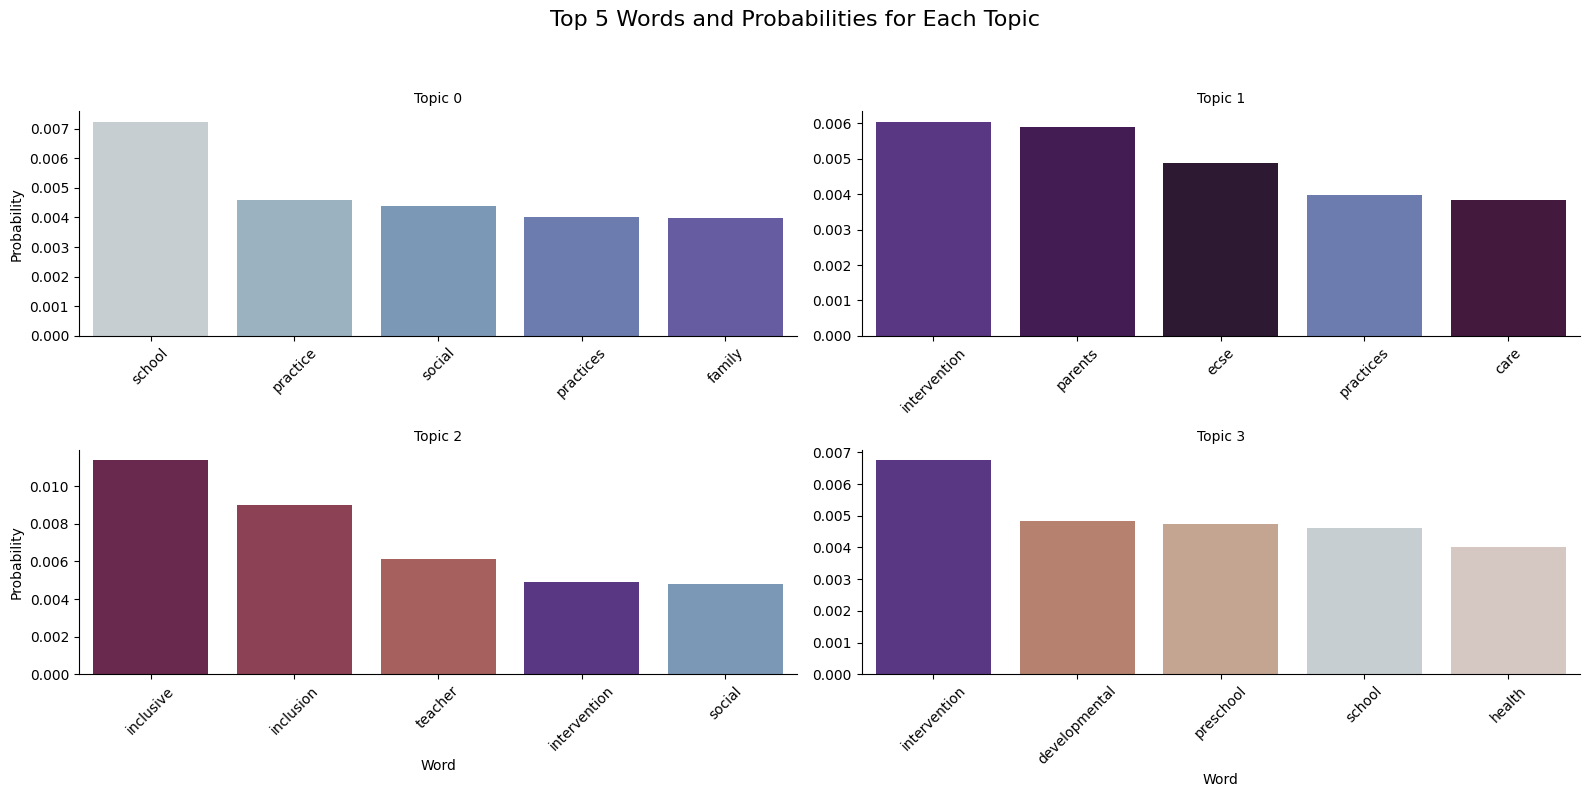

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Create the facet bar plot
g = sns.catplot(data=df_topic_words, x='Word', y='Probability', col='Topic ID', col_wrap=2, kind='bar',
                height=4, aspect=2, hue='Word', legend=False, palette='twilight', sharex=False, sharey=False)

# Customize the plot
g.set_axis_labels("Word", "Probability")
g.set_titles("Topic {col_name}")

# Rotate x-axis labels for better readability
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    ax.tick_params(axis='x', labelbottom=True)

plt.suptitle('Top 5 Words and Probabilities for Each Topic', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

**Topic Labels**:
* Topic 0: Educational Practices and Social Development
* Topic 1: Parent Involvement and ECSE Practices
* Topic 2: Inclusive Education and Teacher Preparation
* Topic 3: Preschool Intervention and Developmental Support

**Which topics appear most distinct?**

Topic 1 appears the most distinct because it includes the specific term “ecse” (early childhood special education), which is not present in the other topics. In addition, it emphasizes parent involvement and intervention practices, making it more clearly focused on family-centered early childhood special education. While all topics are not completely distinct, they still represent different aspects of early childhood disability research.

**Network Analysis**

Fixing the initial seed for the pseudorandom number generator

In [ ]:
%%capture
!pip install textnets

In [ ]:
%%capture
import re
import textnets as tn
tn.params

Text preprocessing for network analysis. This code removes punctuation, HTML/XML tags, stopwords, short tokens, and converts text to lowercase to improve the interpretability of the network analysis. Additionally, all inputs were converted to strings to ensure consistent processing and prevent errors during analysis.

In [ ]:
def clean_doc_network(doc):
    doc = str(doc)

    no_punct = ''
    for c in doc:
        if c not in string.punctuation:
            no_punct = no_punct + c
    # with list comprehension
    # no_punct = ''.join([c for c in doc if c not in string.punctuation])

    # Remove tags like <jats:p>
    no_punct = re.sub(r"<[^>]+>", " ", no_punct)

    words = no_punct.lower().split()

    final_words = []
    for word in words:
        if word not in stop_words and len(word) > 2:
            final_words.append(word)

    return " ".join(final_words)

Applies the preprocessing function to the abstract column, producing a new clean text field to use as input for the network analysis.

In [ ]:
df["network_text"] = df["Abstract"].apply(clean_doc_network)

Set seed for reproducibility.

In [ ]:
tn.params["seed"] = 42

In [ ]:
corpus = tn.Corpus(df["network_text"].dropna(), lang="en")

Creating text network, using a minimum document frequency threshold (min_docs=40) to drop terms that appear in less than 40 documents, as well as remove_weak_edges=True to reduce noise and improve the network clarity.

In [ ]:
t = tn.Textnet(corpus.tokenized(), min_docs=40, remove_weak_edges=True)
t

0docs [00:00, ?docs/s]

Textnet,Docs: 964,Terms: 272,Edges: 21259


Visualize and analyze nodes and clusters

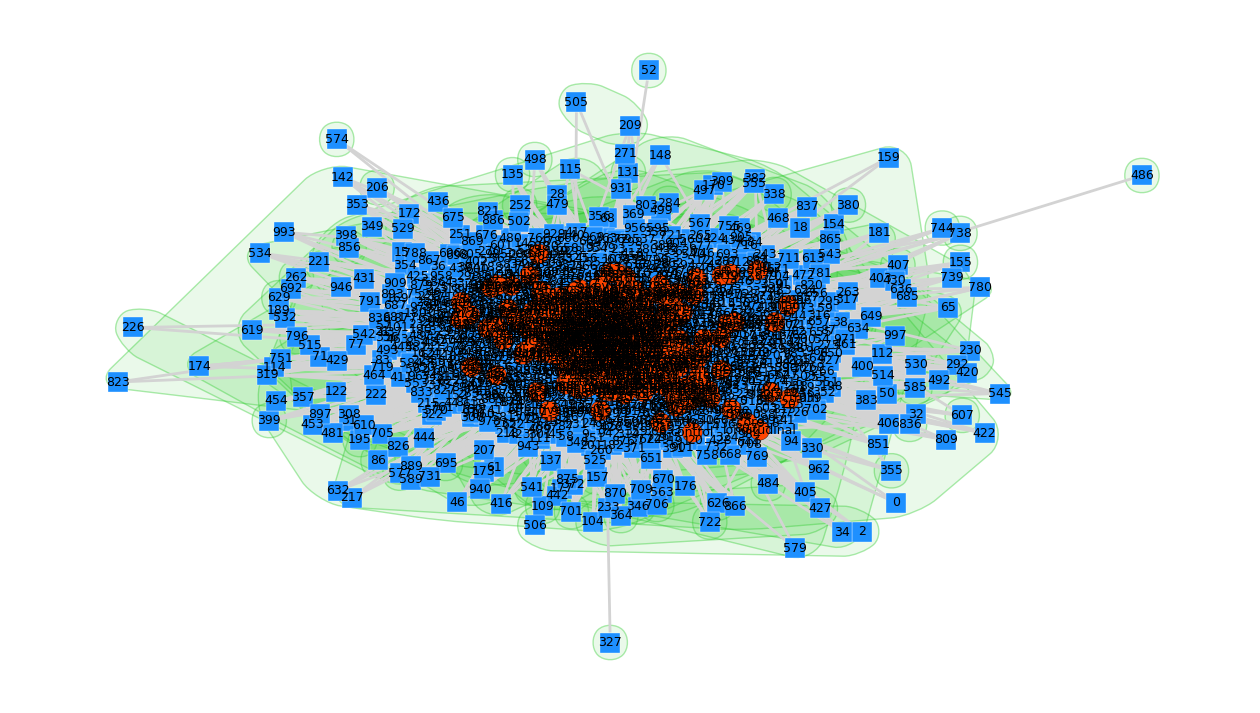

In [ ]:
t.plot(label_nodes=True,
       show_clusters=True)

The text network consists of two node types, documents and terms. The document nodes represent the individual articles in the dataset, while the term nodes represent the words extracted from the abstracts. A connection exists when a term appears in a document, forming a bipartite network. This allows the network to capture how words are distributed across the articles.

Visualize again but scale the nodes according to their birank and the edges according to their weights

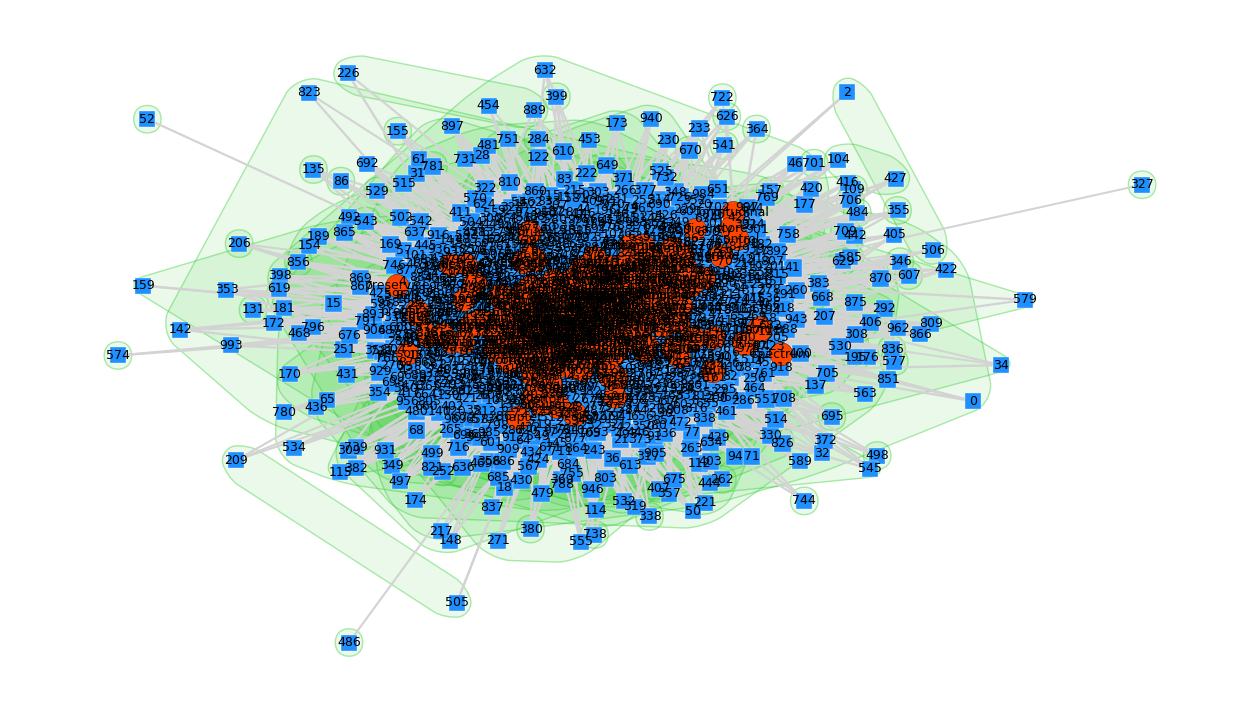

In [ ]:
t.plot(label_nodes=True,
       show_clusters=True,
       scale_nodes_by="birank",
       scale_edges_by="weight")

Using the one-node term-to-term projection, clusters can be interpreted as indicating latent themes

In [ ]:
terms = t.project(node_type=tn.TERM, connected=True)
terms.top_cluster_nodes()

,nodes,size
cluster,,
0,"[practice, professional, teacher, inclusive, s...",117
1,"[school, high, developmental, age, health, rep...",95
2,"[parent, experience, care, finding, child, sur...",50
3,"[united, states, policy, system, change, lack,...",10


Visualize connected networks

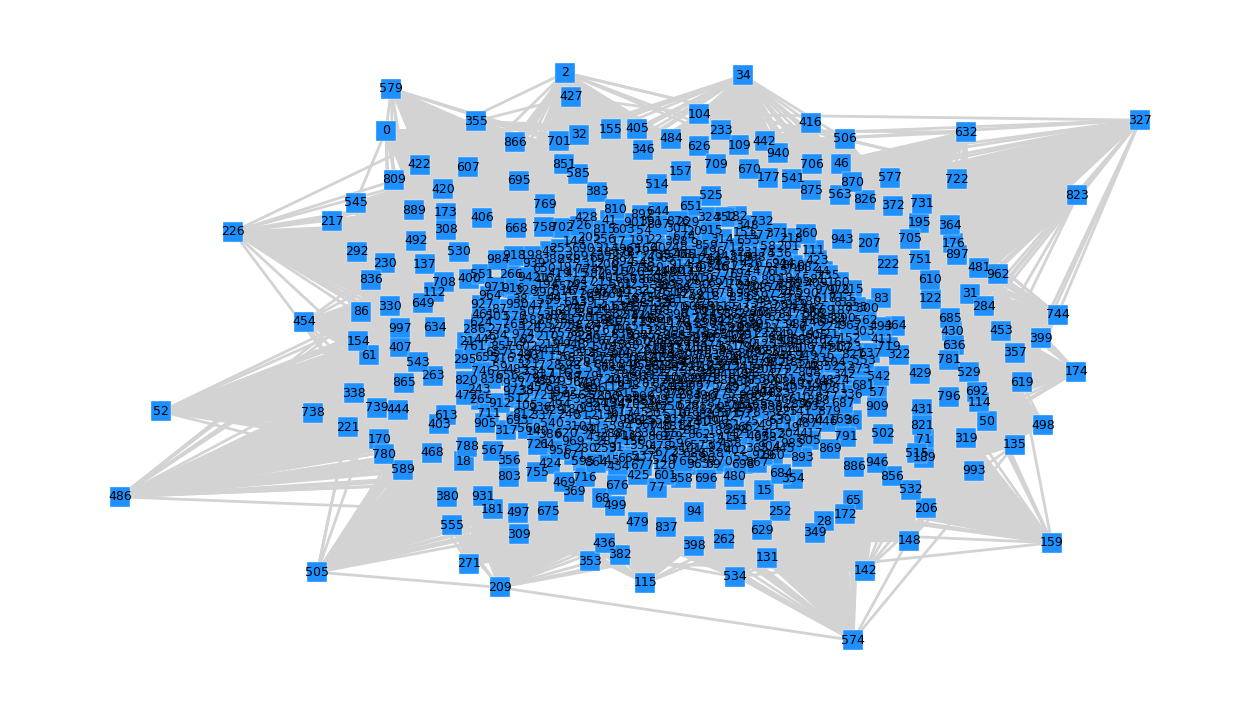

In [ ]:
papers = t.project(node_type=tn.DOC)
papers.plot(label_nodes=True)

Visualizing the term network

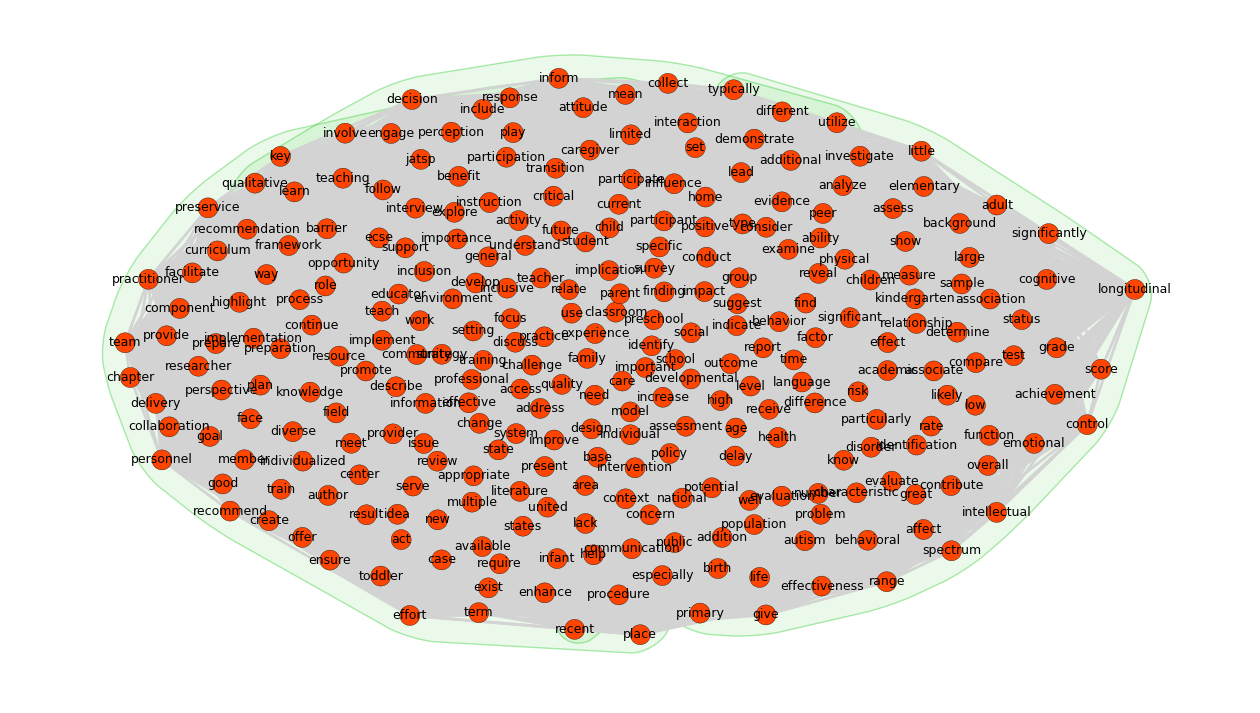

In [ ]:
words = t.project(node_type=tn.TERM)
words.plot(label_nodes=True,
           show_clusters=True)

**Term-network projection:**

* The term–term network represents patterns of co-occurrence between words in the dataset. Instead of grouping words into abstract topics, it shows how terms are directly related based on shared context. This helps reveal how meaning is constructed through relationships between terms, rather than treating words as independent features.
* We used betweenness centrality to identify terms and papers that function as bridges across different parts of the network. The final network visualization scales nodes by betweenness centrality, colors clusters to show groupings, and labels only terms that are above the median betweenness value to improve readability.

In [ ]:
papers.top_betweenness()

,0
183,53084.0
645,47073.0
397,26361.0
883,14318.0
663,12679.0
73,9498.0
638,8597.0
829,7761.0
718,7309.0
171,7014.0


In [ ]:
words.top_betweenness()

,0
school,1600.0
practice,1471.0
experience,327.0
teacher,325.0
developmental,315.0
professional,268.0
parent,212.0
high,209.0
social,196.0
increase,178.0


0edges [00:00, ?edges/s]

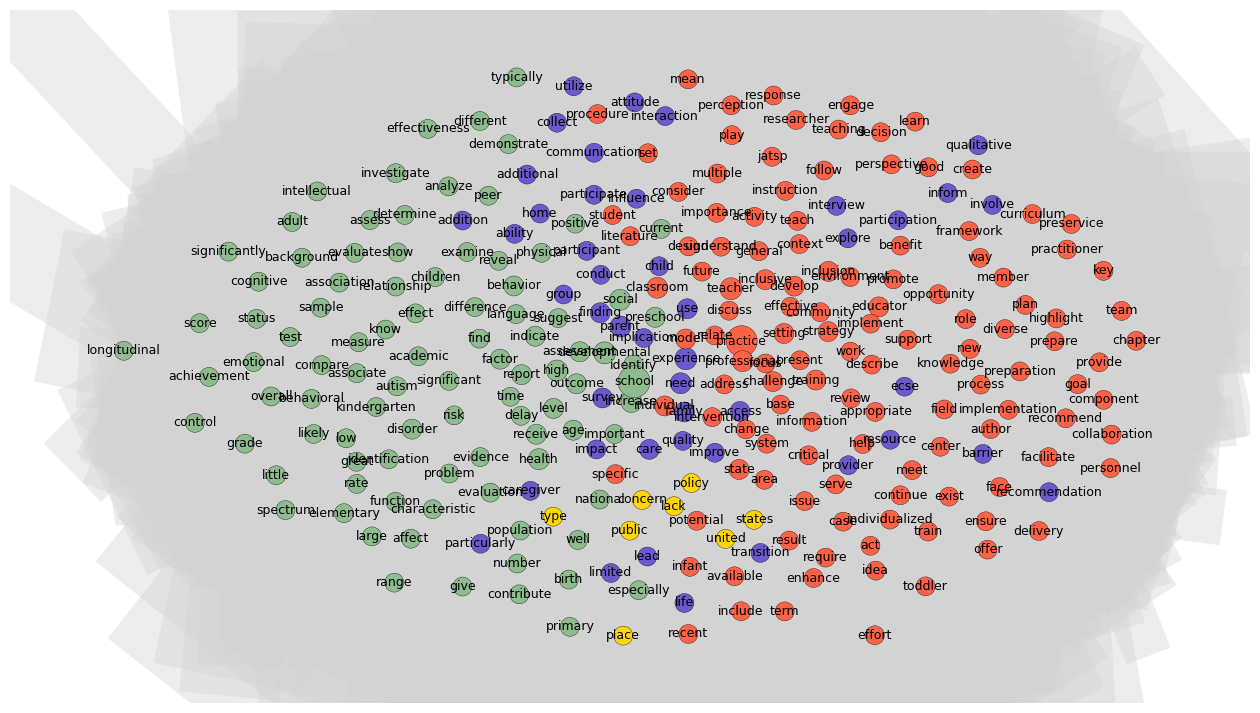

In [ ]:
words.plot(label_nodes=True,
           scale_nodes_by="betweenness",
           color_clusters=True,
           alpha=0.5,
           edge_width=[10*w for w in words.edges["weight"]],
           edge_opacity=0.4,
           node_label_filter=lambda n: n.betweenness() > words.betweenness.median())

The network visualization shows several distinct clusters of related terms, indicating that research in early childhood education and disability is organized around multiple interconnected themes. One cluster reflects instructional practices and educational strategies, with terms related to teaching, curriculum, and implementation. Another cluster emphasizes developmental, behavioral, and health-related aspects, including terms related to child outcomes and assessment.

Nodes with higher betweenness centrality appear between clusters, highlighting key bridging concepts such as intervention and support. These connections suggest that educational practices and developmental outcomes are closely linked in the literature rather than being studied in isolation.

# Machine Learning

Splitting the data into features and target labels. The abstract column is used as the feature because it contains the text data that the model will analyze to learn patterns. The publication year is grouped into “Recent” and “Older” categories and used as the target label, and is what the classifier will attempt to predict.

In [ ]:
features = df["Abstract"]

df["year_group"] = df["Publication Year"].apply(
    lambda year: "Recent" if year >= 2020 else "Older"
)

target = df["year_group"]
target_names = ["Older", "Recent"]

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.pipeline import Pipeline

# split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# Show the results of the split
print("Training set has {} samples.".format(X_train.shape[0]))
print("Testing set has {} samples.".format(X_test.shape[0]))

# Remove or replace NaN values in X_train and X_test
X_train = X_train.fillna('')
X_test = X_test.fillna('')

preprocessing = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer())
])

print("Preprocessing training data...")
train_preprocessed = preprocessing.fit_transform(X_train)

print("Preprocessing test data...")
test_preprocessed = preprocessing.transform(X_test)

Training set has 700 samples.
Testing set has 300 samples.
Preprocessing training data...
Preprocessing test data...


In [ ]:
y_test.unique()

array(['Older', 'Recent'], dtype=object)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

nb_classifier = MultinomialNB()
svm_classifier = LinearSVC()
lr_classifier = LogisticRegression(multi_class="ovr")

print("Training Naive Bayes classifier...")
nb_classifier.fit(train_preprocessed, y_train)

print("Training SVM classifier...")
svm_classifier.fit(train_preprocessed, y_train)

print("Training Logistic Regression classifier...")
lr_classifier.fit(train_preprocessed, y_train)


Training Naive Bayes classifier...
Training SVM classifier...
Training Logistic Regression classifier...


LogisticRegression(multi_class='ovr')

In [ ]:
nb_predictions = nb_classifier.predict(test_preprocessed)
svm_predictions = svm_classifier.predict(test_preprocessed)
lr_predictions = lr_classifier.predict(test_preprocessed)

In [ ]:
import numpy as np

print("NB Accuracy:", np.mean(nb_predictions == y_test))
print("SVM Accuracy:", np.mean(svm_predictions == y_test))
print("LR Accuracy:", np.mean(lr_predictions == y_test))

NB Accuracy: 0.69
SVM Accuracy: 0.8166666666666667
LR Accuracy: 0.7033333333333334


Running classification reports

In [ ]:
from sklearn.metrics import classification_report  # Import classification_report

print(classification_report(y_test, nb_predictions, target_names=target_names))
print(classification_report(y_test, svm_predictions, target_names=target_names))
print(classification_report(y_test, lr_predictions, target_names=target_names))

              precision    recall  f1-score   support

       Older       0.69      1.00      0.82       207
      Recent       0.00      0.00      0.00        93

    accuracy                           0.69       300
   macro avg       0.34      0.50      0.41       300
weighted avg       0.48      0.69      0.56       300

              precision    recall  f1-score   support

       Older       0.81      0.96      0.88       207
      Recent       0.84      0.51      0.63        93

    accuracy                           0.82       300
   macro avg       0.83      0.73      0.75       300
weighted avg       0.82      0.82      0.80       300

              precision    recall  f1-score   support

       Older       0.70      0.99      0.82       207
      Recent       0.75      0.06      0.12        93

    accuracy                           0.70       300
   macro avg       0.73      0.53      0.47       300
weighted avg       0.72      0.70      0.60       300



The Naive Bayes model achieved an accuracy of 0.69, but it failed to correctly classify any recent abstracts, with a recall of 0.00 for that category. This indicates that the model was heavily biased toward predicting the older class and was unable to identify newer abstracts.

The Logistic Regression model performed slightly better, with an accuracy of 0.70, but it still struggled with the recent category, achieving a very low recall of 0.06. This suggests that it also favored the older class and failed to capture distinguishing features of more recent abstracts.

The SVM model performed the best overall, achieving the highest accuracy of 0.82 and a more balanced performance across both categories. It achieved a recall of 0.51 and precision of 0.84 for recent abstracts, indicating that it was more effective at identifying newer abstracts while maintaining strong performance on the older category.

Confusion matrix

(array([0.5, 1.5]), [Text(0.5, 0, 'Older'), Text(1.5, 0, 'Recent')])

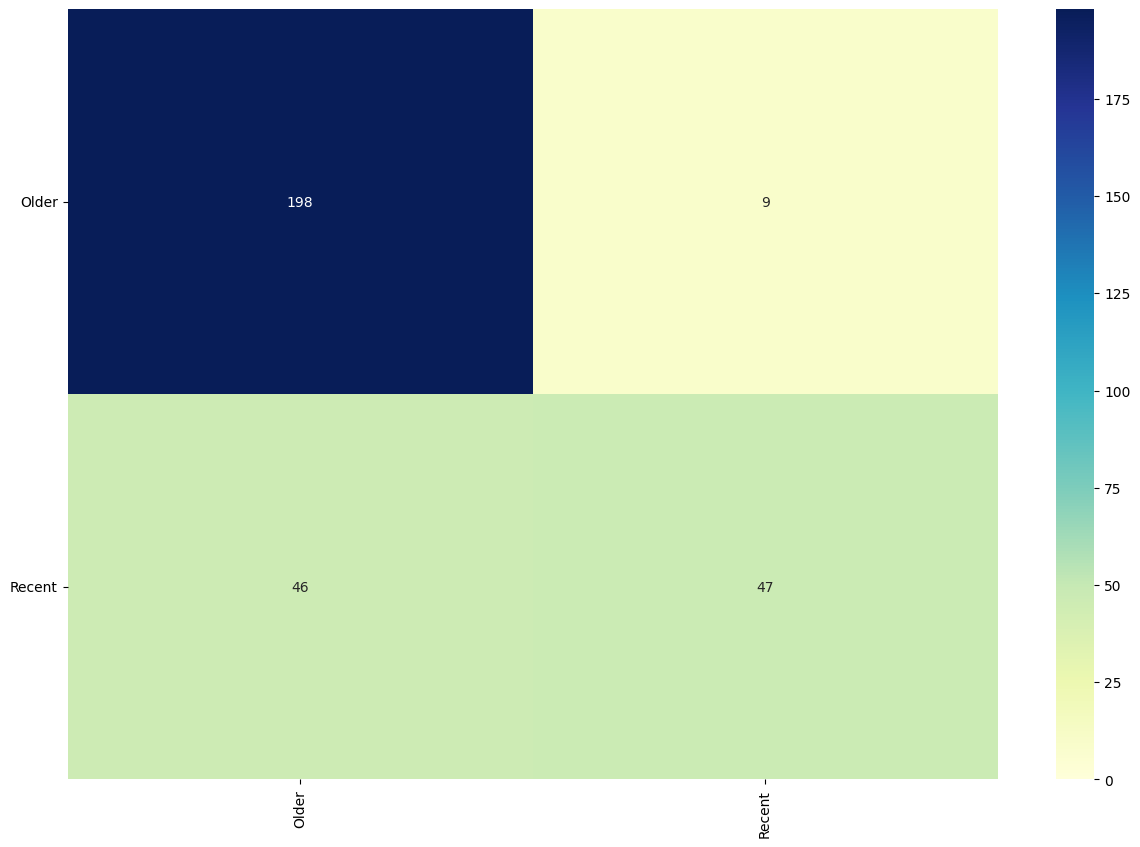

In [ ]:
%matplotlib inline
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_test, svm_predictions)
conf_matrix_df = pd.DataFrame(conf_matrix, index=target_names, columns=target_names)

plt.figure(figsize=(15, 10))
x = sn.heatmap(conf_matrix_df, annot=True, vmin=0, vmax=conf_matrix.max(), fmt='d', cmap="YlGnBu")
plt.yticks(rotation=0)
plt.xticks(rotation=90)

The confusion matrix shows that 198 “Older” abstracts were correctly classified as older (true negatives), while 47 “Recent” abstracts were correctly classified as recent (true positives). The model made some errors, with 9 “Older” abstracts incorrectly classified as recent (false positives) and 46 “Recent” abstracts incorrectly classified as older (false negatives).

Overall, the model performs well at identifying older abstracts, but struggles more with correctly classifying recent abstracts. The higher number of false negatives (46) indicates that many recent abstracts are being misclassified as older, suggesting that the model has a bias toward predicting the “Older” category. This may be due to class imbalance in the dataset where there are more older than recent abstracts, making it more difficult for the model to learn patterns associated with the smaller class. It could also be due to similarities in language across years of publications. While the model achieves reasonable overall accuracy, its lower performance on the “Recent” category highlights a limitation in distinguishing between the two groups based on text features alone.